In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

In [42]:
late = pd.read_excel("/content/drive/MyDrive/late_delivery.xlsx")

In [43]:
X = late[["distance_km", "traffic_level"]]
y = late["late"]

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [45]:
LR = LogisticRegression()
LR.fit(X_train, y_train)

LogisticRegression()

In [46]:
pred = LR.predict(X_test)

In [47]:
print("Late Delivery Accuracy:", accuracy_score(y_test, pred))

Late Delivery Accuracy: 1.0


In [48]:
LR.fit(X, y)


LogisticRegression()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


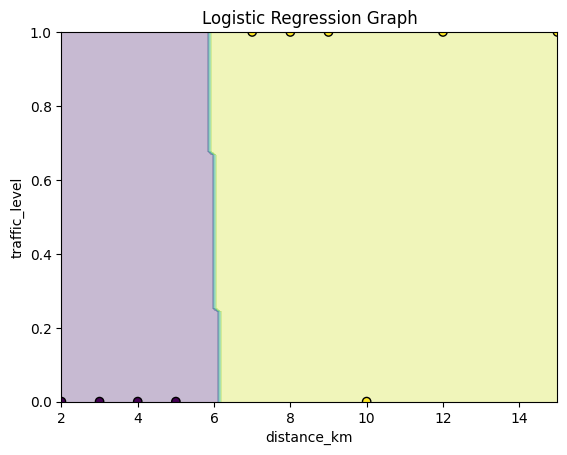

In [49]:
xx, yy = np.meshgrid(
    np.linspace(X.distance_km.min(), X.distance_km.max(), 100),
    np.linspace(X.traffic_level.min(), X.traffic_level.max(), 100)
)

# Predict
Z = LR.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X.distance_km, X.traffic_level, c=y, edgecolors='k')
plt.xlabel("distance_km")
plt.ylabel("traffic_level")
plt.title("Logistic Regression Graph")
plt.show()